#  Fraud Detection Using Machine Learning

## Introduction

The goal of this project is to build a machine learning classification model
that can determine whether a money transaction is fraudulent or not fraudulent.

This is a binary classification problem because there are two possible classes:

 0 → Not Fraud
 
 1 → Fraud

The model will learn patterns from historical transaction data and use those
patterns to classify new transactions.

#### I started to test if the created environment is actually working

In [1]:
import sys

print(sys.executable)

c:\Users\Ms. Winhope\Desktop\FRAUD\env\Scripts\python.exe


##  Import Required Libraries

In this section, I import the Python libraries that will be used for data
loading, exploration, visualization, model training, and
evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##  Load the Dataset

The dataset contains historical money-flow/transaction information.
I will load the data into a pandas DataFrame so that it can be explored
and prepared for machine learning.

In [3]:
df = pd.read_csv("transactions_null.csv")

##  Initial Data Exploration

Before training a model, I need to understand the structure and quality
of the dataset.

I will inspect the first few observations, dataset dimensions, column
names, data types, and missing values.

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [5]:
df.shape

(999999, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            999999 non-null  int64  
 1   type            999999 non-null  str    
 2   amount          999984 non-null  float64
 3   nameOrig        999999 non-null  str    
 4   oldbalanceOrig  999999 non-null  float64
 5   newbalanceOrig  999999 non-null  float64
 6   nameDest        999999 non-null  str    
 7   oldbalanceDest  999999 non-null  float64
 8   newbalanceDest  999999 non-null  float64
 9   isFraud         999999 non-null  int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 76.3 MB


In [7]:
df.isnull().sum()

step               0
type               0
amount            15
nameOrig           0
oldbalanceOrig     0
newbalanceOrig     0
nameDest           0
oldbalanceDest     0
newbalanceDest     0
isFraud            0
dtype: int64

### Missing Values

I checked the dataset for missing values using `isnull().sum()`.

The results show that the `amount` column contains 15 missing values,
while all other columns contain no missing values.

The target variable `isFraud` has no missing values.

## Exploring the Target Variable

The `isFraud` column is the target variable that we want the model to predict.

I will examine the distribution of the two classes to understand how many
transactions are fraudulent and how many are not fraudulent.

In [10]:
df["isFraud"].value_counts()

isFraud
0    999464
1       535
Name: count, dtype: int64

In [12]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.9465
1     0.0535
Name: proportion, dtype: float64

### Class Distribution

The target variable is highly imbalanced. Approximately 99.95% of the
transactions are not fraudulent, while only 0.05% are fraudulent.

Therefore, accuracy alone may not be a reliable metric for evaluating the
fraud detection model because a model could achieve high accuracy by
mostly predicting the majority class.

## Exploring the Features

  Features contain information about different transactions such as transactions type, amount and balance before and after the transactions.

  I will examine the available features before deciding which one to remove and which one to use.

In [14]:
df.dtypes

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrig    float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object

The dataset contains both numerical and categorical features. The numerical
features include transaction amounts and account balances, while `type`,
`nameOrig`, and `nameDest` are categorical/text features.

The target variable `isFraud` is an integer containing the two classes 0 and 1.

## Exploring Transaction Types

The `type` feature describes the type of transaction.
I will examine the unique transaction types and how frequently each type
occurs in the dataset.

In [16]:
df["type"].unique()

<StringArray>
['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
Length: 5, dtype: str

In [19]:
df["type"].value_counts()

type
CASH_OUT    362676
PAYMENT     329752
CASH_IN     218673
TRANSFER     82424
DEBIT         6474
Name: count, dtype: int64

## Fraud Distribution by Transaction Type

I will examine how fraudulent transactions are distributed across the
different transaction types. This may help identify whether certain
transaction types are more associated with fraud.

In [20]:
df.groupby("type")["isFraud"].sum()

type
CASH_IN       0
CASH_OUT    275
DEBIT         0
PAYMENT       0
TRANSFER    260
Name: isFraud, dtype: int64

The fraud cases are concentrated in two transaction types: CASH_OUT and
TRANSFER.

 CASH_OUT contains 275 fraudulent transactions and TRANSFER
contains 260. 

CASH_IN, DEBIT, and PAYMENT contain no fraudulent
transactions in this dataset.

This suggests that transaction type may be an important feature for
classifying fraudulent transactions.

## Exploring Numerical Features

The dataset contains several numerical features related to the transaction
amount and account balances.

I will examine their descriptive statistics to understand their ranges,
central values, and possible unusual values.

In [21]:
df.describe()

,step,amount,oldbalanceOrig,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,999999.000000,9.999840e+05,9.999990e+05,9.999990e+05,9.999990e+05,9.999990e+05,999999.000000
mean,25.156367,1.602520e+05,8.776706e+05,8.983469e+05,9.860678e+05,1.125663e+06,0.000535
std,12.652091,2.592599e+05,2.982421e+06,3.019327e+06,2.305424e+06,2.426588e+06,0.023124
min,1.000000,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,14.000000,1.276069e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,20.000000,7.953939e+04,1.595700e+04,0.000000e+00,1.349307e+05,2.301119e+05,0.000000
75%,38.000000,2.166096e+05,1.397503e+05,1.797897e+05,9.268256e+05,1.167926e+06,0.000000
max,45.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.205466e+07,4.216916e+07,1.000000


After describing numerical features I noticed that

`step` ranges from 1 to 45.

`amount` has a wide range and some very larrge transactions
min=0.1  max=10,000,000.

The balance features also have large ranges.

`amount` has 15 fewer observations because of its missing values(as we have seen it when we calculated Missing values).

`Fraud` confirm the severe class imbalance
mean=0.000535 while my target contains only
 0 = not Fraud 
 1 = Fraud

## Visualizing Numerical Features using Graph

I will visualize the numerical features to better understand their
distributions and identify possible skewness or extreme values that may
not be obvious from the descriptive statistics.

In [23]:
numerical_features = ["step", "amount", "oldbalanceOrig", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

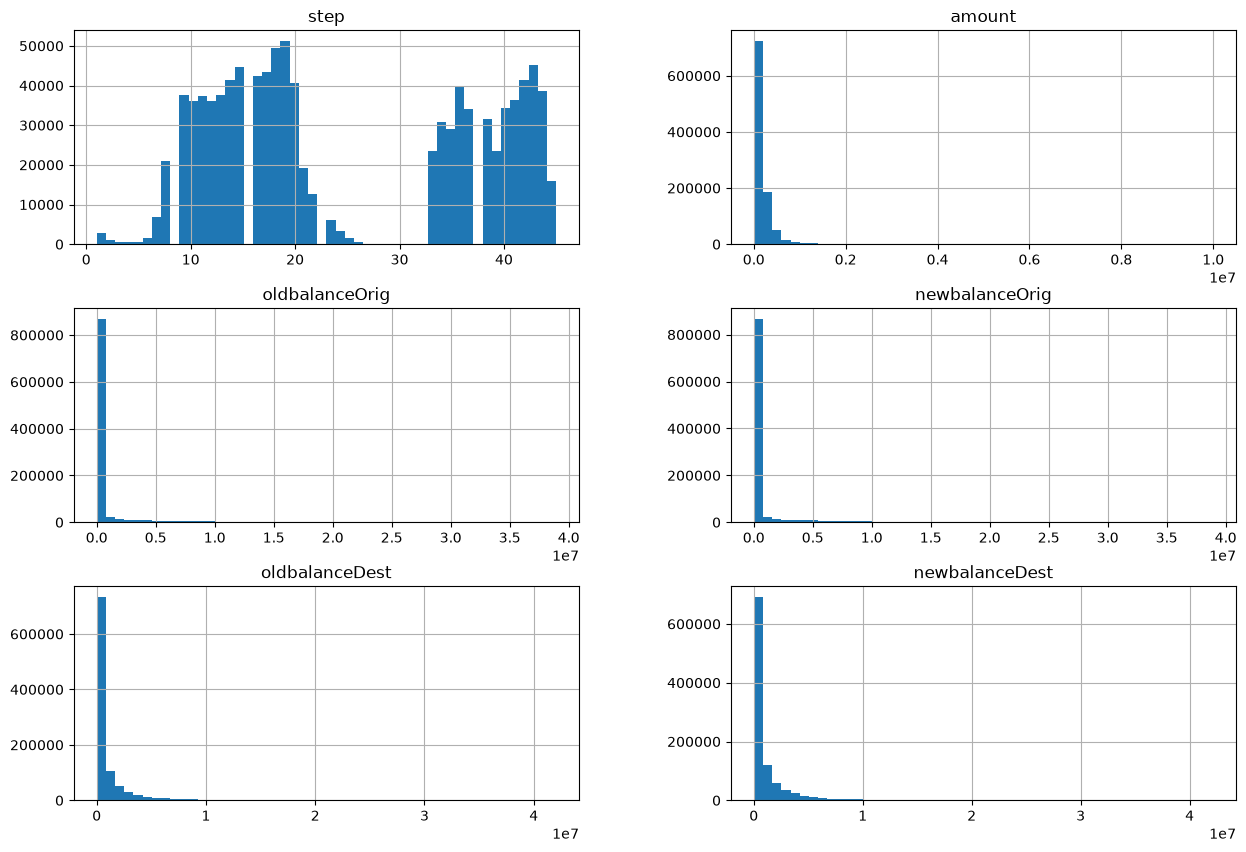

In [25]:
df[numerical_features].hist(bins=50, figsize=(15, 10))
plt.show()

FROM THE GRAPH

-Step has an uneven distribution with distinct groups.

-Amount is strongly right-skewed.

-The balance features are also strongly right-skewed.


## Examining Account Identifiers

The `nameOrig` and `nameDest` columns contain identifiers for the
originating and destination accounts.

I will examine the number of unique values in these columns before
deciding how they should be handled during preprocessing.

In [26]:
df["nameOrig"].nunique()

999758

In [28]:
df["nameDest"].nunique()

422895

## Handling Account Identifiers

The `nameOrig` and `nameDest` columns contain account identifiers
with very high cardinality.

Using one-hot encoding on these columns would create a very large
number of features. Therefore, I will not treat them as standard
categorical variables for the initial model.

For the initial fraud-detection model, these identifier columns
will be removed.

In [29]:
df = df.drop(columns=["nameOrig", "nameDest"])

In [30]:
df.head()

,step,type,amount,oldbalanceOrig,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


## Reviewing the Remaining Features

After removing the high-cardinality account identifiers, I will review
the remaining columns before continuing with categorical encoding and
feature preprocessing.

In [31]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrig', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='str')

In [32]:
df.dtypes

step                int64
type                  str
amount            float64
oldbalanceOrig    float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object

The `type` column is a categorical feature that describes the type
of transaction

## Encoding the Transaction Type

The `type` feature is categorical and contains five categories.

I will use one-hot encoding to convert these categories into
numerical features without introducing an artificial ordering.

One-hot encoding is a technique used to convert categorical (non-numeric) data into a numerical format that machine learning algorithms can understand.

In [35]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
type_encoded = encoder.fit_transform(df[["type"]])

In [36]:
type_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 999999 stored elements and shape (999999, 5)>

This tells us:

999,999 rows → one encoded row for every transaction.

5 columns → one column for each type category.

So our five categories have been successfully converted into numerical features.

## Let's see the actual encoded categories

In [37]:
encoder.categories_

[array(['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER'],
       dtype=object)]

In [38]:
encoder.get_feature_names_out(["type"])

array(['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT',
       'type_TRANSFER'], dtype=object)

This gives us the actual feature names that will be created

## Separating Features and Target

The `isFraud` column is the target variable that the model will
learn to predict.

All other selected columns will be used as input features.

Before combining them, let's separate the features (X) from the target (y)

Example

X → transaction information

y → 0 or 1 (not fraud / fraud)

In [39]:
x = df.drop(columns=["isFraud"])
y = df["isFraud"]

In [40]:
x.head()

,step,type,amount,oldbalanceOrig,newbalanceOrig,oldbalanceDest,newbalanceDest
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0


In [41]:
y.head()

0    0
1    0
2    1
3    1
4    0
Name: isFraud, dtype: int64

## Creating Training and Test Sets

The `isFraud` target is highly imbalanced, with fraudulent transactions
representing only a small proportion of the dataset.

I will split the data into training and test sets using stratification(Stratified splitting)

So that both sets maintain approximately the same proportion of
fraudulent and non-fraudulent transactions.

A stratified split is a way of dividing a dataset into training and testing (or validation) sets while preserving the proportion of each class in every split. It is commonly used in classification problems.


In [59]:
x_train.shape

(799999, 7)

In [60]:
x_test.shape

(200000, 7)

In [61]:
y_train.value_counts()

isFraud
0    799571
1       428
Name: count, dtype: int64

In [62]:
y_test.value_counts()

isFraud
0    199893
1       107
Name: count, dtype: int64

The dataset was successfully divided into training and test sets using
stratification. The training set contains 799,999 transactions and the
test set contains 200,000 transactions.

The proportion of fraudulent transactions is preserved in both sets,
which is important because the dataset is highly imbalanced.

## Building the Preprocessing Pipeline

The dataset contains both numerical and categorical features.
I will use a ColumnTransformer to apply the appropriate preprocessing
to each type of feature.

The numerical features will be passed through unchanged, while the
categorical `type` feature will be one-hot encoded.

In [87]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", "passthrough", numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## Fitting the Preprocessor

The preprocessor will be fitted using only the training data.
After fitting, the same preprocessing rules will be applied to both
the training and test sets.

This prevents information from the test set from influencing the
preprocessing process.

In [71]:
x_train_prepared = preprocessor.fit_transform(x_train)

In [72]:
x_test_prepared = preprocessor.transform(x_test)

Notice the difference

for training preprocessor.fit_transform(X_train)

for testing preprocessor.transform(X_test)

We only transform.

This is important because the test set must remain unseen during the fitting process.

## Checking the Prepared Features

The preprocessing step has converted the categorical `type` feature
into numerical one-hot encoded features while keeping the numerical
features unchanged.

I will check the shape of the prepared training and test datasets
to confirm that the transformation was successful.

In [73]:
x_train_prepared.shape

(799999, 11)

In [76]:
x_test_prepared.shape

(200000, 11)

In [77]:
x_train_prepared[:5]

array([[1.50000000e+01, 8.19259810e+05, 0.00000000e+00, 0.00000000e+00,
        4.22101939e+06, 4.30455429e+06, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
       [4.10000000e+01, 2.89617340e+05, 2.52770000e+04, 0.00000000e+00,
        4.10002283e+06, 4.38964017e+06, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.70000000e+01, 2.05425550e+05, 1.04300000e+04, 0.00000000e+00,
        5.15000000e+04, 2.56925550e+05, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.10000000e+01, 1.50538990e+05, 1.52369000e+05, 1.83001000e+03,
        0.00000000e+00, 1.50538990e+05, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.60000000e+01, 6.77935000e+03, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+

What we observe

The transformation changed:

Training: (799999, 7) → (799999, 11)
Test:     (200000, 7) → (200000, 11)

So our original 7 features became 11 numerical features

## Handling Missing Values

The `amount` feature contains 15 missing values. Since machine-learning
algorithms generally require complete numerical data, I will use
`SimpleImputer` to replace missing numerical values with the median
of the corresponding feature.

In [80]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

We use the median because financial transaction data can contain very large values/outliers, and the median is less affected by extreme values than the mean.

We already created our preprocessor, so rather than creating a separate preprocessing process, we should incorporate the imputer into the numerical part of the pipeline.

In [84]:
from sklearn.pipeline import Pipeline

In [85]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

Update the preprocessing pipeline

In [88]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Fit and transform again

Because we changed the preprocessor, our previous x_train_prepared and x_test_prepared were created before the imputer was added.

We should still have the same shape when we check the results,
The difference is that the missing amount values have now been handled by the numerical pipeline. 

In [90]:
x_train_prepared = preprocessor.fit_transform(x_train)

In [91]:
x_test_prepared = preprocessor.transform(x_test)

In [92]:
x_train_prepared.shape

(799999, 11)

In [93]:
x_test_prepared.shape

(200000, 11)

THE DATA IS NOW READY

## Training a Logistic Regression Baseline

I will use Logistic Regression as the first baseline classifier.
The model will be trained using the preprocessed training data and
evaluated on the unseen test data.

In [94]:
from sklearn.linear_model import LogisticRegression

Create the model:

In [97]:
log_reg = LogisticRegression(max_iter=1000)

Then train it:

In [98]:
log_reg.fit(x_train_prepared, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Now make predictions

In [99]:
y_pred = log_reg.predict(x_test_prepared)

In [100]:
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

The Logistic Regression model predicted the first 20 test
transactions as non-fraudulent.

Because the dataset is highly imbalanced, predictions containing
mostly non-fraudulent transactions are expected. Therefore, additional
classification metrics are required to properly evaluate the model.

## Evaluating the Logistic Regression Model

I will use a confusion matrix to compare the model's predictions
with the actual fraud labels.

The confusion matrix will show how many transactions were correctly
and incorrectly classified as fraudulent or non-fraudulent.

In [101]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[199886,      7],
       [    86,     21]])

Remember the structure
[[TN, FP],
 [FN, TP]]
 
 |                         | Actual Not Fraud | Actual Fraud |
| ----------------------- | ---------------: | -----------: |
| **Predicted Not Fraud** |      **199,886** |       **86** |
| **Predicted Fraud**     |            **7** |       **21** |


 Confusion Matrix Observation

The Logistic Regression model correctly classified 199,886
non-fraudulent transactions and 21 fraudulent transactions.

However, it missed 86 fraudulent transactions and incorrectly
classified 7 non-fraudulent transactions as fraud.

Since detecting fraudulent transactions is important, we need to
examine precision, recall, and F1-score to better evaluate the model.

Precision answers: 
Of all the transactions the model predicted as fraud, how many were actually fraud?

Recall answers: 
Of all the transactions that were actually fraud, how many did the model successfully detect?

F1-score answers: 
How well does the model balance precision and recall?

In [102]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [103]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

precision, recall, f1

(0.75, 0.19626168224299065, 0.3111111111111111)

Classification Metrics Observation

The Logistic Regression model achieved a precision of 0.75, meaning
that most transactions predicted as fraud were actually fraudulent.

However, the recall was only 0.1963, meaning that the model detected
only about 19.6% of the actual fraudulent transactions.

The F1-score was 0.3111, reflecting the difficulty of balancing
precision and recall.

The low recall is a significant limitation because missing fraudulent
transactions is costly in a fraud-detection problem.

## Training an SGD Classifier

I will use a Stochastic Gradient Descent (SGD)
classifier as a binary classification model.

The target variable `isFraud` contains two classes: non-fraudulent (0)
and fraudulent (1).

In [108]:
from sklearn.linear_model import SGDClassifier

In [109]:
sgd_clf = SGDClassifier(random_state=42)

In [110]:
sgd_clf.fit(x_train_prepared, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [111]:
y_sgd_pred = sgd_clf.predict(x_test_prepared)

In [112]:
y_sgd_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Cross-Validation Evaluation

Cross-validation provides a more reliable evaluation of the
SGD classifier by training and evaluating the model on multiple
subsets of the training data.

Because the fraud dataset is highly imbalanced, I will evaluate
the classifier using the F1-score rather than relying only on
accuracy.

In [113]:
from sklearn.model_selection import cross_val_score

In [114]:
sgd_f1_scores = cross_val_score(
    sgd_clf,
    x_train_prepared,
    y_train,
    cv=3,
    scoring="f1"
)

In [116]:
sgd_f1_scores

array([0.0612766 , 0.29360967, 0.20833333])

In [115]:
sgd_f1_scores.mean()

np.float64(0.1877398669753427)

Why F1?

Because our dataset is extremely imbalanced:

Accuracy could make a poor fraud detector look excellent. F1 forces us to consider both precision and recall

Cross-Validation Observation

The SGDClassifier achieved a mean F1-score of approximately 0.1877
using 3-fold cross-validation.

This indicates that the model has difficulty balancing precision and
recall on the highly imbalanced fraud-detection dataset. Further
evaluation using the confusion matrix, precision, and recall is
required.

### Cross-validated predictions
his generates predictions for each training observation without using that observation to train the model that predicts it.

In [117]:
from sklearn.model_selection import cross_val_predict

In [118]:
y_train_pred = cross_val_predict(
    sgd_clf,
    x_train_prepared,
    y_train,
    cv=3
)

In [119]:
cm_sgd = confusion_matrix(y_train, y_train_pred)

cm_sgd

array([[796668,   2903],
       [   206,    222]])

Cross-Validated Confusion Matrix Observation

The cross-validated SGDClassifier correctly detected 222 fraudulent
transactions out of 428 actual fraudulent transactions.

However, it missed 206 fraudulent transactions and incorrectly
classified 2,903 non-fraudulent transactions as fraud.

The confusion matrix shows that the model is detecting a substantial
number of fraudulent transactions, but it also produces a relatively
large number of false positives.

In [120]:
precision_sgd = precision_score(y_train, y_train_pred)
recall_sgd = recall_score(y_train, y_train_pred)
f1_sgd = f1_score(y_train, y_train_pred)

precision_sgd, recall_sgd, f1_sgd

(0.07104, 0.5186915887850467, 0.12496481846327047)

SGD Classification Metrics Observation

The cross-validated SGDClassifier achieved a precision of 0.0710,
a recall of 0.5187, and an F1-score of 0.1250.

The model detected approximately 51.9% of the fraudulent transactions,
which is substantially higher than the recall obtained from our
Logistic Regression baseline.

However, its precision was very low because the model produced many
false-positive predictions. Therefore, the SGDClassifier favors
detecting more fraud at the cost of generating more false alarms.

## Examining Decision Scores

The SGD classifier produces a decision score for each transaction.
The score indicates how strongly the model leans toward one class or
the other.

A negative score indicates a prediction toward non-fraud, while a
positive score indicates a prediction toward fraud.

Examining these scores allows us to adjust the decision threshold and
study the trade-off between precision and recall.

In [121]:
y_scores = cross_val_predict(
    sgd_clf,
    x_train_prepared,
    y_train,
    cv=3,
    method="decision_function"
)

In [122]:
y_scores[:20]

array([-6.80382369e+10, -4.56414498e+10, -8.93391738e+09, -7.99387335e+07,
       -2.69846211e+08, -1.78445129e+09, -2.67096253e+10, -3.19743324e+09,
       -2.14326702e+10, -2.48373055e+10, -2.28513638e+10, -1.47610335e+08,
       -2.98170261e+10, -1.57685095e+10, -1.19288153e+10, -2.87832315e+09,
        1.64922386e+07, -6.58093752e+08, -1.76211410e+10, -1.85349596e+11])

 Observation of Decision Scores

The SGD classifier produces both negative and positive decision scores.
Negative scores indicate that the model leans toward the non-fraud
class, while positive scores indicate that the model leans toward the
fraud class.

The scores are not probabilities and can therefore have very large
positive or negative values. The default classification threshold is
0.

## Precision-Recall Trade-off

The classification threshold determines whether a transaction is
classified as fraudulent.

Lowering the threshold makes the classifier more likely to predict
fraud, which generally increases recall but can reduce precision.

Raising the threshold makes the classifier more conservative, which
can increase precision but reduce recall.

In [123]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_train,
    y_scores
)

In [124]:
len(precisions), len(recalls), len(thresholds)

(799980, 799980, 799979)

Precision-Recall Curve Observation

The precision-recall calculation produced 799,980 precision values and
799,980 recall values corresponding to 799,979 decision thresholds.

There is one more precision and recall value than thresholds because
the precision-recall calculation includes an additional endpoint.

c:\Users\Ms. Winhope\Desktop\FRAUD\env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


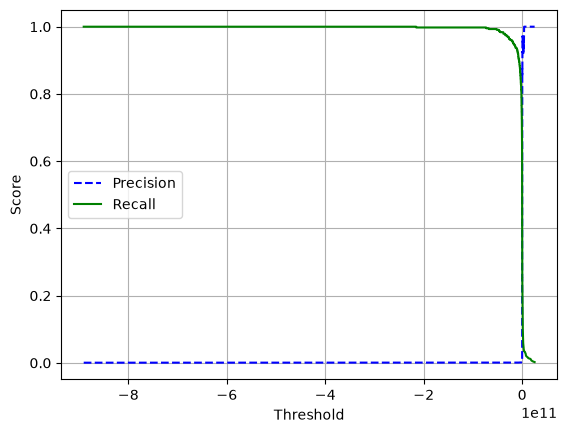

In [125]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

Precision-Recall Trade-off Observation

The graph shows that precision and recall change as the decision
threshold changes. Lower thresholds make the classifier more likely
to identify transactions as fraud, increasing recall, while higher
thresholds make the classifier more selective.

The decision scores have very large values because the numerical
features have different scales. Therefore, feature scaling is
important for the SGD classifier.

## Scaling the Numerical Features

The numerical features have very different scales. For example,
`step` contains relatively small values, while the balance features
can contain values in the millions.

Since SGD-based models are sensitive to feature scale, I will use
`StandardScaler` to standardize the numerical features.

The scaler will be fitted only on the training data through the
preprocessing pipeline.

In [126]:
from sklearn.preprocessing import StandardScaler

In [127]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [128]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [130]:
x_train_prepared = preprocessor.fit_transform(x_train)

In [131]:
x_test_prepared = preprocessor.transform(x_test)

In [132]:
x_train_prepared.shape

(799999, 11)

In [133]:
x_test_prepared.shape

(200000, 11)

What changed?

Previously: Numerical feature - Imputer - Model

Now: Numerical feature - Imputer - StandardScaler - Model

In [134]:
sgd_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SGDClassifier(random_state=42))
])

In [136]:
sgd_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['step','type','amount',...,'newbalanceOrig','oldbalanceDest', 'newbalanceDest']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [138]:
y_pred = sgd_pipeline.predict(x_test)

In [139]:
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [140]:
np.bincount(y_pred)

array([199991,      9])

In [141]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[199891,      2],
       [   100,      7]])

In [142]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.7777777777777778
Recall: 0.06542056074766354
F1: 0.1206896551724138


In [143]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.99949


## Classification Report

Accuracy alone is not sufficient for evaluating this fraud-detection model because the dataset is highly imbalanced.

Therefore, I will use the classification report to examine **precision, recall, and F1-score** for both the non-fraud and fraud classes.


In [152]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199893
           1       0.78      0.07      0.12       107

    accuracy                           1.00    200000
   macro avg       0.89      0.53      0.56    200000
weighted avg       1.00      1.00      1.00    200000



This means

Precision = 0.78 → When the model says a transaction is fraud, it is correct about 78% of the time.

Recall = 0.07 → The model detects only about 7% of the actual fraud cases.

F1 = 0.12 → The balance between precision and recall is poor.

Support = 107 → There are 107 actual fraud transactions in the test set.

The biggest problem is therefore false negatives:

The model is missing most fraudulent transactions.

The 99.949% accuracy should not be our main success metric because the dataset is extremely imbalanced.

## Training a Random Forest Classifier

The scaled SGD classifier achieved very high accuracy, but its recall for the fraud class was low. This means that the model missed most fraudulent transactions.

To improve the model's ability to capture nonlinear relationships between transaction features, I will now train a **Random Forest Classifier**.

Random Forest can combine multiple decision trees and capture complex relationships between variables such as transaction amount, account balances, and transaction type.

The model will use the same preprocessing pipeline so that the numerical features are imputed and the categorical features are encoded consistently.


In [145]:
from sklearn.ensemble import RandomForestClassifier

forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [147]:
forest_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['step','type','amount',...,'newbalanceOrig','oldbalanceDest', 'newbalanceDest']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [148]:
forest_pred = forest_pipeline.predict(x_test)

Evaluating the Random Forest Classifier

The Random Forest model has now been trained on the training data.

I will first examine its confusion matrix to determine how many fraudulent and non-fraudulent transactions the model correctly and incorrectly classified.


In [149]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, forest_pred)

array([[199892,      1],
       [    43,     64]])

|              | Predicted 0 | Predicted 1 |
| ------------ | ----------: | ----------: |
| **Actual 0** |     199,892 |           1 |
| **Actual 1** |          43 |          64 |


-TN = 199,892 — legitimate transactions correctly identified.

-FP = 1 — only 1 legitimate transaction incorrectly flagged.

-FN = 43 — 43 fraud cases missed.

-TP = 64 — 64 fraud cases correctly detected.

## Precision, Recall, and F1-Score

The confusion matrix shows that the Random Forest classifier detects substantially more fraudulent transactions than the SGD classifier.

I will now calculate precision, recall, and F1-score to quantitatively evaluate the model's performance, with particular attention to the fraud class.


In [150]:
from sklearn.metrics import precision_score, recall_score, f1_score

forest_precision = precision_score(y_test, forest_pred)
forest_recall = recall_score(y_test, forest_pred)
forest_f1 = f1_score(y_test, forest_pred)

print("Precision:", forest_precision)
print("Recall:", forest_recall)
print("F1:", forest_f1)

Precision: 0.9846153846153847
Recall: 0.5981308411214953
F1: 0.7441860465116279


 Random Forest Classification Report

The Random Forest classifier performs substantially better than the SGD classifier on the fraud class.

The classification report provides precision, recall, F1-score, and support for both non-fraudulent and fraudulent transactions, allowing us to evaluate the model in more detail.


In [151]:
from sklearn.metrics import classification_report

print(classification_report(y_test, forest_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199893
           1       0.98      0.60      0.74       107

    accuracy                           1.00    200000
   macro avg       0.99      0.80      0.87    200000
weighted avg       1.00      1.00      1.00    200000



| Model             |  Precision |     Recall |         F1 |
| ----------------- | ---------: | ---------: | ---------: |
| SGD + Scaling     |     77.78% |      6.54% |     12.07% |
| **Random Forest** | **98.46%** | **59.81%** | **74.42%** |


## Cross-Validation of the Random Forest

A single train-test split can sometimes give an overly optimistic or pessimistic estimate of model performance.

To obtain a more reliable evaluation, I will use **cross-validation** on the training data. This allows the model to be trained and evaluated on multiple different subsets of the training data.

Because this is a fraud-detection problem with a highly imbalanced target, I will use **StratifiedKFold** so that each fold maintains approximately the same proportion of fraudulent and non-fraudulent transactions.

I will evaluate the model using the **F1-score**, which balances precision and recall for the fraud class.


In [153]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

Create folds

In [154]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [156]:
cv_scores = cross_val_score(
    forest_pipeline,
    x_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation F1 scores: [0.80272109 0.65151515 0.75177305 0.72463768 0.77464789]
Mean F1: 0.7410589716158559
Standard deviation: 0.051639089603930516


This tells us
Mean F1 = 0.741 → On average, the Random Forest achieves about 74.1% F1 across the five folds.

Standard deviation = 0.052,

The lowest score is 0.652, while the highest is 0.803.

WHEN YOU COMPARE THE MODELS
| Model                |  Precision |     Recall |         F1 |
| -------------------- | ---------: | ---------: | ---------: |
| SGD + StandardScaler |     77.78% |      6.54% |     12.07% |
| **Random Forest**    | **98.46%** | **59.81%** | **74.42%** |

And Random Forest's cross-validation:

Mean F1 = 74.11% ± 5.16%

So for now, Random Forest is clearly our preferred model.


## SELECTING THE FINAL MODEL
I trained and evaluated Logistic Regression, SGDClassifier, and Random Forest models.

Random Forest was selected as the preferred model because it achieved the highest fraud-class F1-score (74.42%),
higher recall (59.81%) while maintaining very high precision (98.46%).

 Its 5-fold cross-validation produced a mean F1-score of 74.11%, indicating reasonably consistent performance. Therefore, among the models evaluated in this project, Random Forest was the best-performing model for the fraud-detection task.

SAVE THE MODEL

In [163]:
import joblib

joblib.dump(forest_pipeline, "fraud_detection_random_forest.pkl")

['fraud_detection_random_forest.pkl']

In [164]:
import os

os.path.exists("fraud_detection_random_forest.pkl")

True

In [168]:
loaded_model = joblib.load("fraud_detection_random_forest.pkl")

loaded_predictions = loaded_model.predict(x_test)

print("Model loaded successfully.")
print("Predictions match:", (loaded_predictions == forest_pred).all())

Model loaded successfully.
Predictions match: True
